# Visualizing hypothesis embeddings with PCA

`diversity` and `size_of_leap` both work in a 768-dimensional `specter2` embedding
space. This notebook projects that space down to 2D with PCA so you can see how spread out a tool's hypotheses are from each other
(diversity), and how close each one sits to the nearest thing already in the literature (size of leap).

PCA to 2 components from 768 dimensions is a lossy linear projection. The 2D picture is for intuition, not
a replacement for the real cosine-distance numbers the metrics use -
the last section of this notebook checks, for the specific capture you load,
how much of the real distance structure survives the projection.


In [1]:
import os
import sys
from pathlib import Path

# Run from anywhere -- resolve the project root relative to this notebook.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "benchmarking_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from benchmarking_pipeline.axes.novelty.diversity import Diversity
from benchmarking_pipeline.axes.novelty.size_of_leap import _nearest_neighbor, _paper_text
from benchmarking_pipeline.core.config import RunConfig
from benchmarking_pipeline.core.context import Context
from benchmarking_pipeline.core.models import EvaluationRun, Tool
from benchmarking_pipeline.io.parsers import parse_json
from benchmarking_pipeline.services.embeddings import SPECTER2, SentenceTransformerEmbedding, cosine_similarity
from benchmarking_pipeline.services.literature import CompositeLiteratureClient

# --- Config: point this at any captured hypothesis set under data/captures/ ---
CAPTURE_PATH = "data/captures/dmri_extracted.json"
RUN_PROMPT = "novel hypotheses for efficient multi-compartment model selection in diffusion MRI"
LITERATURE_MAILTO = None  # optional: your email, for CrossRef's polite pool (higher rate limits)

# The real fix from this session's investigation: size_of_leap's nearest-neighbor
# search is judge-gated for topical relevance (a bibliographic search can return
# a paper that shares generic wording -- "model misspecification", "meta-learning"
# -- while being from a completely unrelated field). Set this True (and have
# OPENAI_API_KEY set) to see the metric's real, production behavior -- it will
# correctly leave some hypotheses unassessed rather than plot a wrong match.
# False shows the raw best-embedding-similarity match with no relevance check,
# which is faster, deterministic, and needs no API key, but can occasionally be
# wrong -- run it both ways to see the difference the judge gate makes.
USE_JUDGE = False

hyps = parse_json(CAPTURE_PATH).hypotheses
print(f"Loaded {len(hyps)} hypotheses from {CAPTURE_PATH}")
for h in hyps:
    print(f"  H{h.rank}: {h.text}")


Loaded 5 hypotheses from data/captures/dmri_extracted.json
  H1: Model-discriminative closed-loop acquisition driven by the PRISM posterior
  H2: Model selection via amortized misspecification detection: selecting the simplest model the data does not reject
  H3: Equivalence-class selection: choosing among gauge-equivalent models via downstream-task invariance
  H4: Cross-tissue transfer of the model posterior via meta-learning on the compartment-library structure
  H5: Conformalized model selection with finite-sample coverage guarantees


## Part 1 -- Diversity: how spread are the hypotheses from each other?

Each hypothesis's own text (not its claims) gets embedded, and `diversity`
reports the mean pairwise cosine distance across the set. Plotted in 2D, a
tight cluster of points is what "clustered / redundant" looks like; points
spread across the plane is "broadly spread."


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

diversity score: 0.1382 (clustered / redundant)


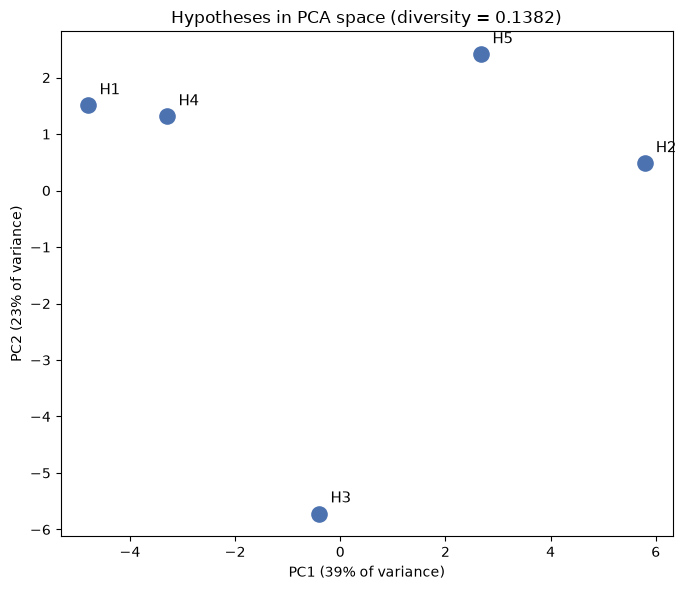

In [2]:
embed = SentenceTransformerEmbedding(SPECTER2)
hyp_vectors = embed.embed([h.text for h in hyps])

# The real metric, run on this same capture, for a number to compare the plot against.
run = EvaluationRun(tool=Tool(name="notebook"), prompt=RUN_PROMPT,
                    outputs=parse_json(CAPTURE_PATH))
diversity_result = Diversity().score(run.outputs, run, Context(config=RunConfig(), embeddings=embed))
print(f"diversity score: {diversity_result.score} ({diversity_result.anchor})")

pca_hyps = PCA(n_components=2)
coords_hyps = pca_hyps.fit_transform(hyp_vectors)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coords_hyps[:, 0], coords_hyps[:, 1], s=120, color="#4C72B0")
for i, h in enumerate(hyps):
    ax.annotate(f"H{h.rank}", coords_hyps[i], textcoords="offset points", xytext=(8, 8), fontsize=11)
ax.set_title(f"Hypotheses in PCA space (diversity = {diversity_result.score})")
ax.set_xlabel(f"PC1 ({pca_hyps.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca_hyps.explained_variance_ratio_[1]:.0%} of variance)")
plt.tight_layout()
plt.show()


## Part 2 -- Size of leap: how far is each hypothesis from its nearest literature neighbor?

This reuses `_nearest_neighbor` directly from `size_of_leap.py` -- not a
reimplementation -- so whatever it plots is exactly what the real metric
computes, including the claims-based query enrichment and (if `USE_JUDGE=True`)
the topical-relevance gate. Each hypothesis and its nearest neighbor are
embedded and projected into the *same* PCA space (fit on both together), then
connected with a line -- a short line means "restates existing work," a long
one means "far from anything found."


In [3]:
lit = CompositeLiteratureClient(mailto=LITERATURE_MAILTO)
judge = None
if USE_JUDGE:
    from benchmarking_pipeline.services.llm_judge import OpenAIJudge
    judge = OpenAIJudge("gpt-4o-mini")

ctx = Context(config=RunConfig(), embeddings=embed, literature=lit, judge=judge)

neighbor_titles, neighbor_vectors, unassessed_reasons = [], [], []
for h in hyps:
    result = _nearest_neighbor(h, ctx, prompt=RUN_PROMPT)
    if isinstance(result, str):
        neighbor_titles.append(None)
        neighbor_vectors.append(None)
        unassessed_reasons.append(result)
        continue
    distance, record, similarity = result
    neighbor_titles.append(record.title)
    neighbor_vectors.append(embed.embed([_paper_text(record)])[0])
    unassessed_reasons.append(None)

for h, title, reason in zip(hyps, neighbor_titles, unassessed_reasons):
    print(f"H{h.rank}: {h.text[:60]}")
    print(f"   -> {title if title else f'[unassessed: {reason}]'}")


H1: Model-discriminative closed-loop acquisition driven by the P
   -> Model Selection and Estimation of Multi-compartment Models in Diffusion MRI with a Rician Noise Model
H2: Model selection via amortized misspecification detection: se
   -> Partial Identification versus Model Misspecification: Is Honesty Best?
H3: Equivalence-class selection: choosing among gauge-equivalent
   -> [unassessed: no_literature_found]
H4: Cross-tissue transfer of the model posterior via meta-learni
   -> Two tissue compartment model in DCE-MRI: A bayesian approach
H5: Conformalized model selection with finite-sample coverage gu
   -> Data-free model stealing via active latent perturbation and sample selection


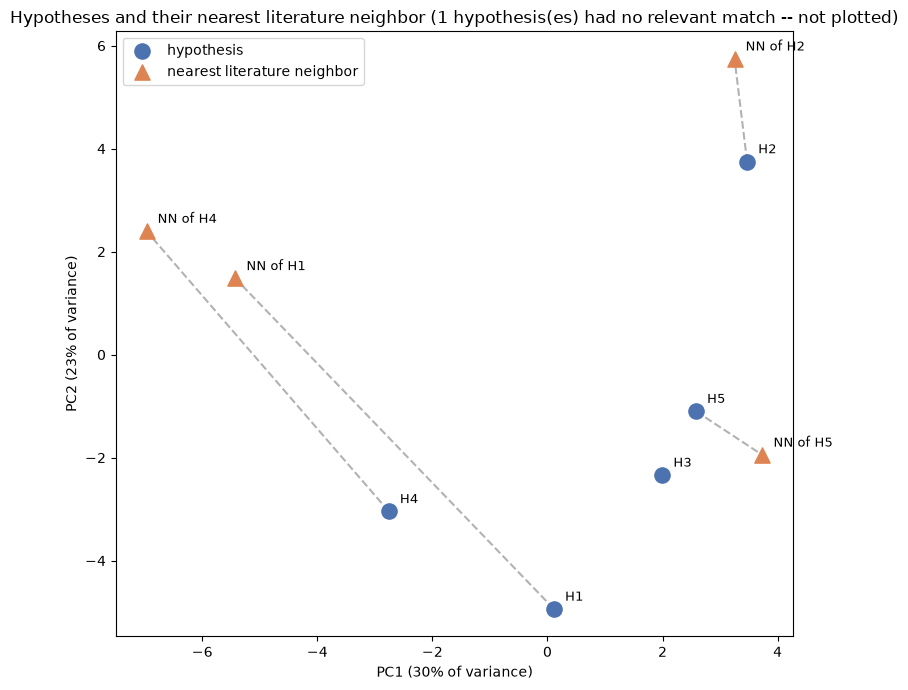

In [4]:
# Combine hypotheses + their neighbors into one shared PCA space.
combined_vectors = [hyp_vectors[i] for i in range(len(hyps))]
combined_labels = [f"H{h.rank}" for h in hyps]
combined_is_neighbor = [False] * len(hyps)
neighbor_index_of = {}  # hypothesis index -> index in combined_vectors of its neighbor

for i, vec in enumerate(neighbor_vectors):
    if vec is not None:
        neighbor_index_of[i] = len(combined_vectors)
        combined_vectors.append(vec)
        combined_labels.append(f"NN of H{hyps[i].rank}")
        combined_is_neighbor.append(True)

pca_combined = PCA(n_components=2)
coords_combined = pca_combined.fit_transform(np.vstack(combined_vectors))

fig, ax = plt.subplots(figsize=(8, 7))
is_neighbor = np.array(combined_is_neighbor)
ax.scatter(coords_combined[~is_neighbor, 0], coords_combined[~is_neighbor, 1],
          s=120, color="#4C72B0", label="hypothesis", zorder=3)
ax.scatter(coords_combined[is_neighbor, 0], coords_combined[is_neighbor, 1],
          s=120, color="#DD8452", marker="^", label="nearest literature neighbor", zorder=3)
for i, label in enumerate(combined_labels):
    ax.annotate(label, coords_combined[i], textcoords="offset points", xytext=(8, 6), fontsize=9)
for h_idx, nn_idx in neighbor_index_of.items():
    ax.plot(*zip(coords_combined[h_idx], coords_combined[nn_idx]), "--", color="gray", alpha=0.6, zorder=1)

n_unassessed = sum(r is not None for r in unassessed_reasons)
title = "Hypotheses and their nearest literature neighbor"
if n_unassessed:
    title += f" ({n_unassessed} hypothesis(es) had no relevant match -- not plotted)"
ax.set_title(title)
ax.set_xlabel(f"PC1 ({pca_combined.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca_combined.explained_variance_ratio_[1]:.0%} of variance)")
ax.legend()
plt.tight_layout()
plt.show()


## Fidelity check -- how much does the 2D projection distort the real distances?

The metrics use full 768-dimensional cosine distance, not the 2D picture above.
This compares the two directly: for every pair of hypotheses, the real cosine
distance vs. the Euclidean distance between their PCA-projected points. A
correlation close to 1.0 means the plot is a faithful stand-in for the real
distances; a lower one means the plot is showing you a distorted picture and
you should trust the numbers, not your eyes, for this particular capture.


PC1+PC2 explain 61.9% of the embedding's variance
correlation between real cosine distance and 2D plot distance: 0.750


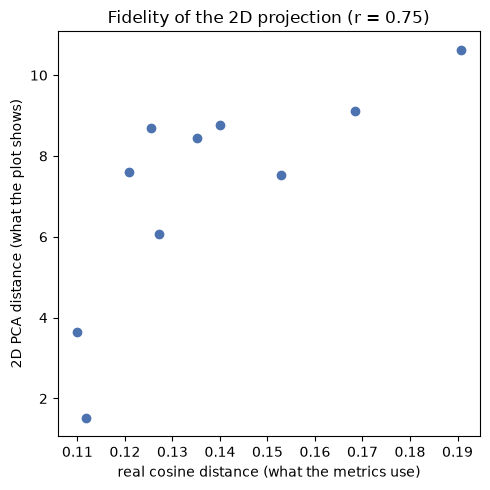

In [5]:
real_dists, plot_dists = [], []
for i in range(len(hyps)):
    for j in range(i + 1, len(hyps)):
        real_dists.append(1 - cosine_similarity(hyp_vectors[i], hyp_vectors[j]))
        plot_dists.append(float(np.linalg.norm(coords_hyps[i] - coords_hyps[j])))

corr = np.corrcoef(real_dists, plot_dists)[0, 1]
variance_kept = pca_hyps.explained_variance_ratio_.sum()
print(f"PC1+PC2 explain {variance_kept:.1%} of the embedding's variance")
print(f"correlation between real cosine distance and 2D plot distance: {corr:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(real_dists, plot_dists, color="#4C72B0")
ax.set_xlabel("real cosine distance (what the metrics use)")
ax.set_ylabel("2D PCA distance (what the plot shows)")
ax.set_title(f"Fidelity of the 2D projection (r = {corr:.2f})")
plt.tight_layout()
plt.show()
